In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [2]:
# Load Vietnam stock data

vn_path = "../data/vietnam/stock-historical-data"
ticker_file = "FPT-VNINDEX-History.csv" 
df = pd.read_csv(os.path.join(vn_path, ticker_file))

df = df.drop(columns=["Unnamed: 0"], errors="ignore")

df["TradingDate"] = pd.to_datetime(df["TradingDate"], errors="coerce")
df = df.dropna(subset=["TradingDate"])
df = df.sort_values("TradingDate").reset_index(drop=True)

df.head()

,Open,High,Low,Close,Volume,TradingDate
0,15710.0,15710.0,15710.0,15710.0,83530,2006-12-13
1,16495.0,16495.0,16495.0,16495.0,280710,2006-12-14
2,17320.0,17320.0,17320.0,17320.0,265300,2006-12-15
3,18184.0,18184.0,18184.0,18184.0,215790,2006-12-18
4,19087.0,19087.0,19087.0,19087.0,137520,2006-12-19


In [3]:
# ============================================================
# Feature engineering for trading signals
# ============================================================

df["Daily_Return"] = df["Close"].pct_change()

df["SMA_5"] = df["Close"].rolling(window=5).mean()
df["SMA_20"] = df["Close"].rolling(window=20).mean()

df["EMA_12"] = df["Close"].ewm(span=12, adjust=False).mean()
df["EMA_26"] = df["Close"].ewm(span=26, adjust=False).mean()

df["MACD"] = df["EMA_12"] - df["EMA_26"]

df["Volatility_10"] = df["Daily_Return"].rolling(window=10).std()

# RSI calculation
delta = df["Close"].diff()

gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss
df["RSI"] = 100 - (100 / (1 + rs))

df = df.dropna().reset_index(drop=True)

df.head()

,Open,High,Low,Close,Volume,TradingDate,Daily_Return,SMA_5,SMA_20,EMA_12,EMA_26,MACD,Volatility_10,RSI
0,19245.0,19441.0,19245.0,19441.0,314250,2007-01-10,0.010184,19182.0,18292.20,18636.199652,17919.408664,716.790988,0.034236,46.575980
1,19637.0,19637.0,19637.0,19637.0,283920,2007-01-11,0.010082,19401.8,18488.55,18790.168936,18046.637652,743.531284,0.031635,53.768394
2,20619.0,20619.0,20619.0,20619.0,279710,2007-01-12,0.050008,19637.4,18694.75,19071.527561,18237.183011,834.344550,0.034647,65.996181
3,21012.0,21640.0,21012.0,21640.0,274290,2007-01-15,0.049517,20116.4,18910.75,19466.677167,18489.243529,977.433639,0.031527,77.834922
4,22701.0,22701.0,22701.0,22701.0,339760,2007-01-16,0.049030,20807.6,19136.60,19964.265295,18801.225490,1163.039806,0.023933,78.472222


In [4]:
# ============================================================
# Create labels for Buy and Sell signal
# ============================================================

future_window = 7

df["Future_Close"] = df["Close"].shift(-future_window)

df["Future_Return"] = (
    df["Future_Close"] - df["Close"]
) / df["Close"]

# Buy if future return > 1%
df["Buy_Signal"] = (df["Future_Return"] > 0.01).astype(int)

# Sell if future return < -2%
df["Sell_Signal"] = (df["Future_Return"] < -0.02).astype(int)

df = df.dropna().reset_index(drop=True)

df[["TradingDate", "Close", "Future_Return", "Buy_Signal", "Sell_Signal"]].head()

,TradingDate,Close,Future_Return,Buy_Signal,Sell_Signal
0,2007-01-10,19441.0,0.167687,1,0
1,2007-01-11,19637.0,0.200031,1,0
2,2007-01-12,20619.0,0.146661,1,0
3,2007-01-15,21640.0,0.052634,1,0
4,2007-01-16,22701.0,0.003436,0,0


In [5]:
# Check class balance

print("Buy signal distribution:")
print(df["Buy_Signal"].value_counts())

print("\nSell signal distribution:")
print(df["Sell_Signal"].value_counts())

Buy signal distribution:
Buy_Signal
0    2276
1    1736
Name: count, dtype: int64

Sell signal distribution:
Sell_Signal
0    2892
1    1120
Name: count, dtype: int64


In [6]:
# ============================================================
# Select features
# ============================================================

features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Daily_Return",
    "SMA_5",
    "SMA_20",
    "MACD",
    "Volatility_10",
    "RSI"
]

data = df[features].copy()

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

scaled_data.shape

(4012, 11)

In [7]:
# ============================================================
# Helper functions
# ============================================================

def create_classification_dataset(scaled_data, labels, window_size):
    X = []
    y = []

    for i in range(window_size, len(scaled_data)):
        X.append(scaled_data[i-window_size:i])
        y.append(labels[i])

    return np.array(X), np.array(y)


def chronological_split(X, y, train_ratio=0.7, val_ratio=0.15):
    train_size = int(len(X) * train_ratio)
    val_size = int(len(X) * val_ratio)

    X_train = X[:train_size]
    y_train = y[:train_size]

    X_val = X[train_size:train_size + val_size]
    y_val = y[train_size:train_size + val_size]

    X_test = X[train_size + val_size:]
    y_test = y[train_size + val_size:]

    return X_train, X_val, X_test, y_train, y_val, y_test


def build_signal_cnn_model(window_size, num_features):
    model = Sequential()

    model.add(
        Conv1D(
            filters=64,
            kernel_size=3,
            activation="relu",
            input_shape=(window_size, num_features)
        )
    )

    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.2))

    model.add(Flatten())

    model.add(Dense(64, activation="relu"))
    model.add(Dropout(0.2))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


def evaluate_classifier(y_true, y_prob, title):
    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(title)
    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    return acc, precision, recall, f1

In [8]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

In [9]:
window_size = 30

buy_labels = df["Buy_Signal"].values

X_buy, y_buy = create_classification_dataset(
    scaled_data,
    buy_labels,
    window_size
)

X_train_buy, X_val_buy, X_test_buy, y_train_buy, y_val_buy, y_test_buy = chronological_split(
    X_buy,
    y_buy
)

print(X_train_buy.shape, y_train_buy.shape)
print(X_val_buy.shape, y_val_buy.shape)
print(X_test_buy.shape, y_test_buy.shape)

(2787, 30, 11) (2787,)
(597, 30, 11) (597,)
(598, 30, 11) (598,)


In [10]:
buy_model = build_signal_cnn_model(
    window_size=window_size,
    num_features=len(features)
)

buy_model.summary()

d:\Study Documents\Fulbright\2026 Spring\Deep Learning for Artificial Intelligence\DL_Final_Project\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 28, 64)         │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        57,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,649 (233.00 KB)

 Trainable params: 59,649 (233.00 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# ============================================================
# Compute class weights for Buy model
# ============================================================

classes_buy = np.unique(y_train_buy)

weights_buy = compute_class_weight(
    class_weight='balanced',
    classes=classes_buy,
    y=y_train_buy
)

class_weights_buy = dict(zip(classes_buy, weights_buy))

print(class_weights_buy)

{np.int64(0): np.float64(0.8476277372262774), np.int64(1): np.float64(1.2191601049868765)}


In [12]:
history_buy = buy_model.fit(
    X_train_buy,
    y_train_buy,
    validation_data=(X_val_buy, y_val_buy),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights_buy,
    verbose=1
)

Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5005 - loss: 0.6933 - val_accuracy: 0.5126 - val_loss: 0.7032
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5289 - loss: 0.6888 - val_accuracy: 0.5092 - val_loss: 0.6988
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5386 - loss: 0.6819 - val_accuracy: 0.4673 - val_loss: 0.7094
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5590 - loss: 0.6760 - val_accuracy: 0.4640 - val_loss: 0.7149
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5666 - loss: 0.6724 - val_accuracy: 0.4807 - val_loss: 0.7571
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5770 - loss: 0.6672 - val_accuracy: 0.4707 - val_loss: 0.7489
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5784 - loss: 0.6644 - val_accuracy: 0.4824 - val_loss: 0.7831
Epoch 8/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5956 - loss: 0.6559 - val_accuracy: 0.4824 - 

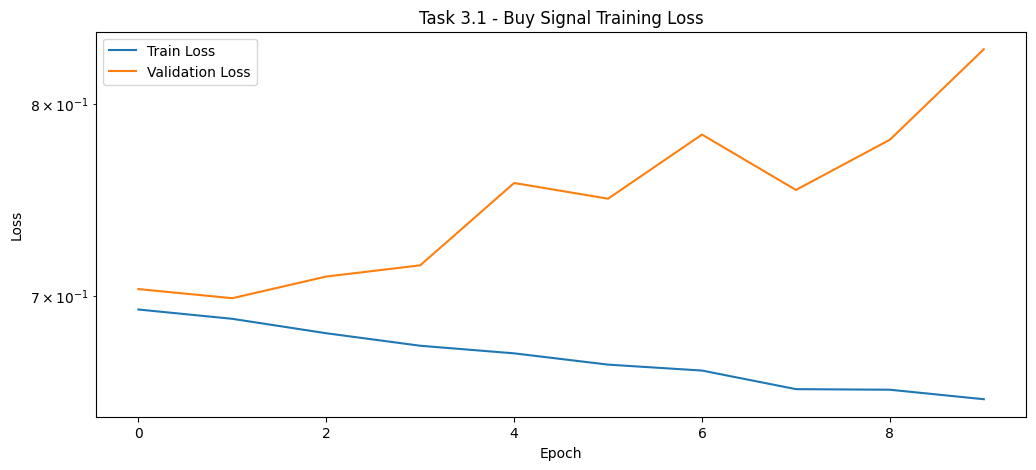

In [13]:
plt.figure(figsize=(12,5))

plt.plot(history_buy.history["loss"], label="Train Loss")
plt.plot(history_buy.history["val_loss"], label="Validation Loss")

plt.yscale("log")

plt.title("Task 3.1 - Buy Signal Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig(
    "../results/figures/task3_1_buy_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
buy_prob = buy_model.predict(X_test_buy)

buy_acc, buy_precision, buy_recall, buy_f1 = evaluate_classifier(
    y_test_buy,
    buy_prob,
    "Task 3.1 - Buy Signal Identification"
)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Task 3.1 - Buy Signal Identification
Accuracy: 0.5267558528428093
Precision: 0.0
Recall: 0.0
F1-score: 0.0

Classification Report:
              precision    recall  f1-score   support

           0       0.53      1.00      0.69       315
           1       0.00      0.00      0.00       283

    accuracy                           0.53       598
   macro avg       0.26      0.50      0.35       598
weighted avg       0.28      0.53      0.36       598


Confusion Matrix:
[[315   0]
 [283   0]]


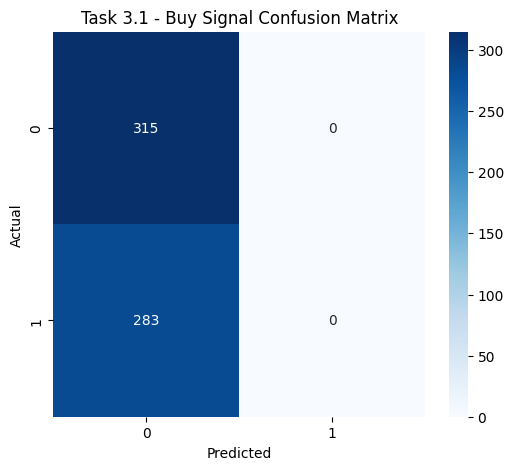

In [16]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

buy_pred_binary = (
    buy_prob >= 0.5
).astype(int)

cm_buy = confusion_matrix(
    y_test_buy,
    buy_pred_binary
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_buy,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Task 3.1 - Buy Signal Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "../results/figures/task3_1_buy_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
buy_model.save(
    "../models/task3_1_buy_signal_classifier.keras"
)

In [18]:
sell_labels = df["Sell_Signal"].values

X_sell, y_sell = create_classification_dataset(
    scaled_data,
    sell_labels,
    window_size
)

X_train_sell, X_val_sell, X_test_sell, y_train_sell, y_val_sell, y_test_sell = chronological_split(
    X_sell,
    y_sell
)

print(X_train_sell.shape, y_train_sell.shape)
print(X_val_sell.shape, y_val_sell.shape)
print(X_test_sell.shape, y_test_sell.shape)

(2787, 30, 11) (2787,)
(597, 30, 11) (597,)
(598, 30, 11) (598,)


In [19]:
sell_model = build_signal_cnn_model(
    window_size=window_size,
    num_features=len(features)
)

sell_model.summary()

d:\Study Documents\Fulbright\2026 Spring\Deep Learning for Artificial Intelligence\DL_Final_Project\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 28, 64)         │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        57,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,649 (233.00 KB)

 Trainable params: 59,649 (233.00 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# ============================================================
# Compute class weights for Sell model
# ============================================================

classes_sell = np.unique(y_train_sell)

weights_sell = compute_class_weight(
    class_weight='balanced',
    classes=classes_sell,
    y=y_train_sell
)

class_weights_sell = dict(zip(classes_sell, weights_sell))

print(class_weights_sell)

{np.int64(0): np.float64(0.7087995930824008), np.int64(1): np.float64(1.697320341047503)}


In [21]:
history_sell = sell_model.fit(
    X_train_sell,
    y_train_sell,
    validation_data=(X_val_sell, y_val_sell),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights_sell,
    verbose=1
)

Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5608 - loss: 0.6838 - val_accuracy: 0.4858 - val_loss: 0.7282
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6204 - loss: 0.6707 - val_accuracy: 0.6214 - val_loss: 0.6788
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6114 - loss: 0.6622 - val_accuracy: 0.5394 - val_loss: 0.7069
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6143 - loss: 0.6515 - val_accuracy: 0.4238 - val_loss: 0.8313
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6032 - loss: 0.6485 - val_accuracy: 0.6064 - val_loss: 0.6821
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6143 - loss: 0.6412 - val_accuracy: 0.6281 - val_loss: 0.6594
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6193 - loss: 0.6382 - val_accuracy: 0.6499 - val_loss: 0.6319
Epoch 8/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6096 - loss: 0.6311 - val_accuracy: 0.6080 - 

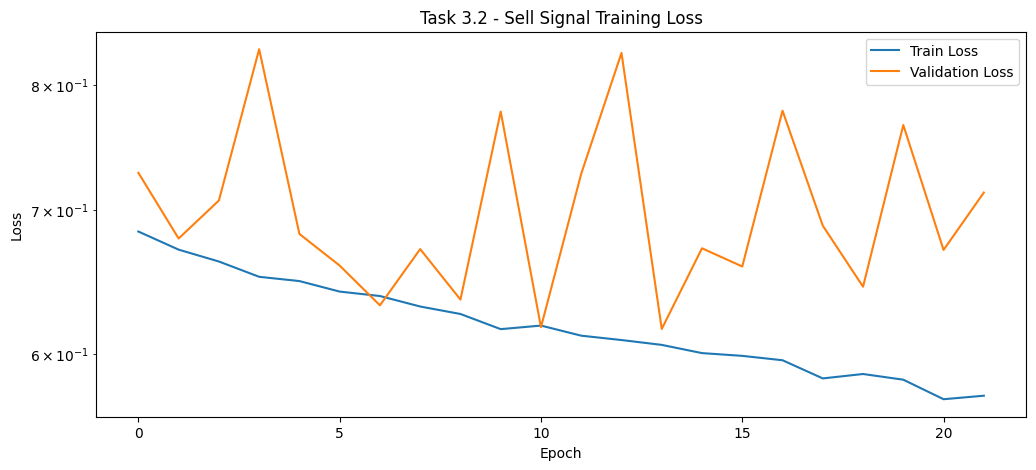

In [22]:
plt.figure(figsize=(12,5))

plt.plot(history_sell.history["loss"], label="Train Loss")
plt.plot(history_sell.history["val_loss"], label="Validation Loss")

plt.yscale("log")

plt.title("Task 3.2 - Sell Signal Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig(
    "../results/figures/task3_2_sell_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
sell_prob = sell_model.predict(X_test_sell)

sell_acc, sell_precision, sell_recall, sell_f1 = evaluate_classifier(
    y_test_sell,
    sell_prob,
    "Task 3.2 - Sell Signal Identification"
)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Task 3.2 - Sell Signal Identification
Accuracy: 0.7424749163879598
Precision: 0.07692307692307693
Recall: 0.006993006993006993
F1-score: 0.01282051282051282

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.97      0.85       455
           1       0.08      0.01      0.01       143

    accuracy                           0.74       598
   macro avg       0.42      0.49      0.43       598
weighted avg       0.59      0.74      0.65       598


Confusion Matrix:
[[443  12]
 [142   1]]


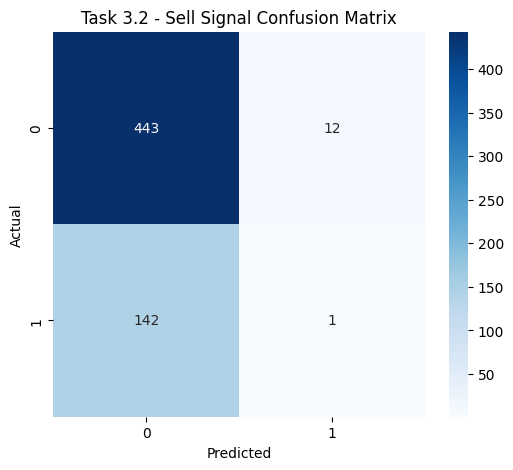

In [24]:
sell_pred_binary = (
    sell_prob >= 0.5
).astype(int)

cm_sell = confusion_matrix(
    y_test_sell,
    sell_pred_binary
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_sell,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Task 3.2 - Sell Signal Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "../results/figures/task3_2_sell_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
sell_model.save(
    "../models/task3_2_sell_signal_classifier.keras"
)

In [27]:
task3_results = pd.DataFrame({
    "Task": [
        "Task 3.1 - Buy Signal Identification",
        "Task 3.2 - Sell Signal Identification"
    ],

    "Model": [
        "CNN Binary Classifier",
        "CNN Binary Classifier"
    ],

    "Accuracy": [
        buy_acc,
        sell_acc
    ],

    "Precision": [
        buy_precision,
        sell_precision
    ],

    "Recall": [
        buy_recall,
        sell_recall
    ],

    "F1": [
        buy_f1,
        sell_f1
    ]
})

task3_results

,Task,Model,Accuracy,Precision,Recall,F1
0,Task 3.1 - Buy Signal Identification,CNN Binary Classifier,0.526756,0.000000,0.000000,0.000000
1,Task 3.2 - Sell Signal Identification,CNN Binary Classifier,0.742475,0.076923,0.006993,0.012821


In [28]:
task3_results.to_csv(
    "../results/metrics/task3_signal_metrics.csv",
    index=False
)

print("Task 3 metrics saved successfully.")

Task 3 metrics saved successfully.


In [29]:
task3_results_rounded = task3_results.copy()

metric_cols = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]

task3_results_rounded[metric_cols] = (
    task3_results_rounded[metric_cols]
    .round(4)
)

task3_results_rounded.to_csv(
    "../results/tables/task3_signal_results_table.csv",
    index=False
)

task3_results_rounded

,Task,Model,Accuracy,Precision,Recall,F1
0,Task 3.1 - Buy Signal Identification,CNN Binary Classifier,0.5268,0.0000,0.000,0.0000
1,Task 3.2 - Sell Signal Identification,CNN Binary Classifier,0.7425,0.0769,0.007,0.0128
